# Imports

In [9]:
import torch
from torch import nn
from torch.nn import CrossEntropyLoss
from segmentation_models_pytorch.losses import DiceLoss
from torch.utils.data import DataLoader
from torchvision import transforms
import matplotlib.pyplot as plt
from LabelMapper import LabelMapper
from RuralDataset import RuralDataset
from SegmentationModel import SegmentationModel
from Trainer import Trainer
from Evaluator import Evaluator
from ImageProcessor import ImageProcessor
torch.cuda.empty_cache()

# Configuration parameters

In [10]:
DATA_ROOT = 'train'
BATCH_SIZE = 16
LEARNING_RATE = 0.0001
NUM_EPOCHS = 25
NUM_CLASSES = 9
MODEL_SAVE_PATH = 'saved_model.pth'

# Device configuration

In [11]:
if torch.cuda.is_available():
    device = torch.device('cuda')  # Configura per utilizzare la GPU
    print(f"Utilizzo GPU: {torch.cuda.get_device_name(0)}")
else:
    device = torch.device('cpu')  # Fallback alla CPU
    print("CUDA non disponibile, utilizzo CPU")

Utilizzo GPU: NVIDIA GeForce RTX 5070 Ti


# Transforms initialization

In [12]:
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(512, scale=(0.8, 1.0), ratio=(0.9, 1.1)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.2),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.RandomRotation(degrees=10),
    transforms.RandomAffine(degrees=0, translate=(0.05, 0.05), scale=(0.95, 1.05), shear=5),
    transforms.RandomPerspective(distortion_scale=0.1, p=0.3),
    transforms.GaussianBlur(kernel_size=5, sigma=(0.1, 2.0)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])
val_transform = transforms.Compose([
    transforms.Resize((512,512)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# Dataset loading and splitting into training and validation sets

In [13]:
# Crea dataset separati con le rispettive trasformazioni
from torch.utils.data import random_split

# Applica la trasformazione di training e validazione ai rispettivi dataset
full_dataset = RuralDataset(root_dir=DATA_ROOT, augment=True)
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size

# Suddividi il dataset in train e val
train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])

# Applica le trasformazioni ai sotto-dataset
# NOTA: random_split restituisce Subset, quindi bisogna settare la transform manualmente
train_dataset.dataset.transform = train_transform
val_dataset.dataset.transform = val_transform

train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, num_workers=16, shuffle=True,
    pin_memory=True)
val_loader = DataLoader(
    val_dataset, batch_size=BATCH_SIZE, num_workers=16, shuffle=False,
    pin_memory=True)

print(f"Training on {len(train_dataset)} samples, validating on {len(val_dataset)} samples.")

Training on 1489 samples, validating on 373 samples.


# Model initialization

In [14]:
model = SegmentationModel(NUM_CLASSES)
model.to(device)
print("Model architecture:")
print(model)

Model architecture:
SegmentationModel(
  (model): Unet(
    (encoder): ResNetEncoder(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): BasicBlock(
          (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (relu): ReLU(inplace=True)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        )
        (1): BasicBlock(
          (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=F

# Loss Function and optimizer definition

In [15]:
#weights =[ 3.8332,  1.0790,  0.7218,  0.7481,  0.8233,  0.3108,  1.7673, 70.4379, 12.8048]
weights = Trainer.compute_class_weights(train_loader, num_classes=NUM_CLASSES)
# Definizione della funzione di loss combinata
cross_entropy = CrossEntropyLoss(weight=torch.tensor(weights, dtype=torch.float32).to(device))
dice_loss = DiceLoss(mode='multiclass')
def combined_loss(pred, target):
    return cross_entropy(pred, target) + dice_loss(pred, target)
criterion = combined_loss

C:\Users\thatsrux\AppData\Local\Temp\ipykernel_12028\4274843505.py:4: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  cross_entropy = CrossEntropyLoss(weight=torch.tensor(weights, dtype=torch.float32).to(device))


In [16]:
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

# Trainer initialization and training


Starting training...

Epoch 1/25
Batch 1/94, Loss: 3.2017
Batch 2/94, Loss: 3.1829
Batch 3/94, Loss: 3.2425
Batch 4/94, Loss: 3.1157
Batch 5/94, Loss: 3.1762
Batch 6/94, Loss: 3.1171
Batch 7/94, Loss: 3.0576
Batch 8/94, Loss: 2.9041
Batch 9/94, Loss: 2.9109
Batch 10/94, Loss: 2.8945
Batch 11/94, Loss: 2.9374
Batch 12/94, Loss: 3.0032
Batch 13/94, Loss: 2.8780
Batch 14/94, Loss: 2.7640
Batch 15/94, Loss: 2.7592
Batch 16/94, Loss: 2.8750
Batch 17/94, Loss: 2.7421
Batch 18/94, Loss: 2.8058
Batch 19/94, Loss: 2.6944
Batch 20/94, Loss: 2.7550
Batch 21/94, Loss: 2.6674
Batch 22/94, Loss: 2.8041
Batch 23/94, Loss: 2.7603
Batch 24/94, Loss: 2.6011
Batch 25/94, Loss: 2.6525
Batch 26/94, Loss: 2.7777
Batch 27/94, Loss: 2.5113
Batch 28/94, Loss: 2.6459
Batch 29/94, Loss: 2.7348
Batch 30/94, Loss: 2.6847
Batch 31/94, Loss: 2.7207
Batch 32/94, Loss: 2.5849
Batch 33/94, Loss: 2.9504
Batch 34/94, Loss: 2.4418
Batch 35/94, Loss: 2.5971
Batch 36/94, Loss: 2.6157
Batch 37/94, Loss: 2.4833
Batch 38/94, 

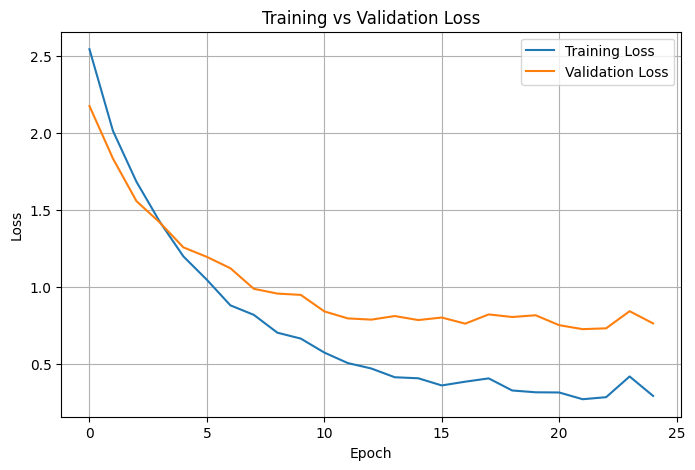

Training finished.


In [17]:
trainer = Trainer(model, train_loader, val_loader, criterion, optimizer, device)
print("\nStarting training...")
trainer.run(num_epochs=NUM_EPOCHS, model_save_path=MODEL_SAVE_PATH)
print("Training finished.")

# Model evaluation

In [18]:
model.load_state_dict(torch.load(MODEL_SAVE_PATH))

evaluator = Evaluator(model, val_loader, device)
metrics = evaluator.evaluate_classification_metrics()

# Example Predict

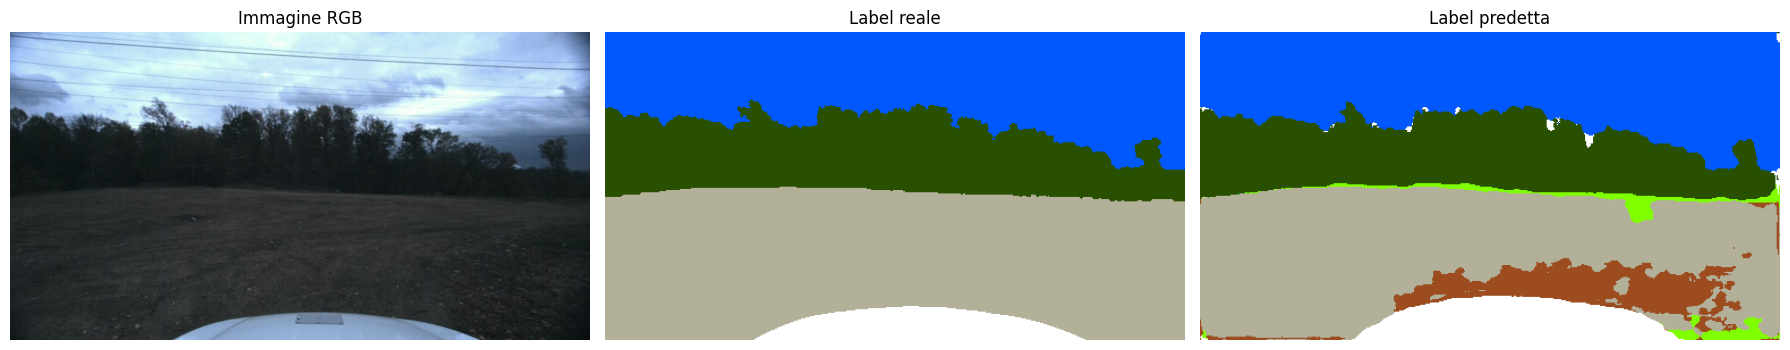

Pixel classificati correttamente: 124447 / 139264 (89.36%)
IoU medio sull'immagine: 0.4503
IoU per classe: [0.97987488 0.         0.78654985 0.         0.93549238 0.
        nan        nan]


In [26]:
evaluator.predict_from_folder(folder_number = 17)

In [20]:
print(metrics.get('accuracy', 'N/A'))
print(metrics.get('f1_score', 'N/A'))
print(metrics.get('precision', 'N/A'))
print(metrics.get('recall', 'N/A'))

0.8977269231474112
N/A
0.8358489644749978
0.8823003721066448
